In [1]:
# ── Cell 1 — imports, path & reload ───────────────────────────────────────────
import sys, os, importlib, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))

import numpy as np
import matplotlib.pyplot as plt
import xso
from xso.parscans import run_xso_parscan, run_xso_stabilityscan, avg_tail

import cariaco_obs as co
import cariaco_baseline_setups as cbs
import parscan_utils as pu
import parscan_plots as pp
for m in (co, cbs, pu, pp):            # pick up edits without a kernel restart
    importlib.reload(m)

phyto_esd, zoo_esd = cbs.phyto_esd, cbs.zoo_esd
print(f'grid: {len(phyto_esd)} phyto ({phyto_esd[0]:.2g}–{phyto_esd[-1]:.0f} µm), '
      f'{len(zoo_esd)} zoo ({zoo_esd[0]:.2g}–{zoo_esd[-1]:.0f} µm)')

grid: 40 phyto (0.2–200 µm), 40 zoo (2–2000 µm)


In [2]:
# === Cell 1: setup — forcing, scan axes, binning machinery, obs target ===
import numpy as np, importlib
import cariaco_baseline_setups as cbs
import cariaco_obs as co
import parscan_utils as pu
import matplotlib.pyplot as plt
from xso.parscans import run_xso_parscan
for m in (cbs, co, pu): importlib.reload(m)

# Upwelling forcing (Inflow__FN, Inflow__de, Temperature__value) + R0-tuned overrides
_, _, bin_defs, monthly_up, forcing_up = co.load_cariaco_targets(
    'upwelling', months='hplc', agg='median', include_temperature=True)
N = cbs.N_CLASSES
fixed = {**forcing_up, 'Grazing__KsZ': np.full(N, 0.30), 'ZooLoss__rate': 0.3}

# Scan axes  (diatom_exp = -0.45 reproduces R0; > 0 = large cells grow faster)
EXP_VALS    = np.round(np.linspace(-0.45, 0.20, 14), 4)
THRESH_VALS = [5.0, 10.0, 20.0, 40.0]    # crossover ESD [µm], straddling Nano/Micro

# Binning (identical operator to the obs side)
phyto_esd = cbs.phyto_esd
W         = pu.phyto_bin_matrix(phyto_esd, bin_defs)        # (3, N): Pico/Nano/Micro
geomeans  = pu.CARIACO_PHYTO_BIN_GEOMEANS                   # [0.63, 6.3, 63.0]
TAIL      = 1000

# Obs upwelling target: per-month fractions -> median
pcols    = [b['column'] for b in bin_defs if b['type'] == 'phyto']
Pobs     = monthly_up[pcols].dropna().values
obs_frac = np.nanmedian(Pobs / Pobs.sum(axis=1, keepdims=True), axis=0)
obs_mcs  = np.nanmedian(10.0 ** ((Pobs / Pobs.sum(axis=1, keepdims=True)) @ np.log10(geomeans)))
print('obs upwelling  Pico/Nano/Micro =', np.round(obs_frac, 3), ' mcs =', round(obs_mcs, 2), 'µm')

obs upwelling  Pico/Nano/Micro = [0.448 0.224 0.313]  mcs = 4.84 µm


In [4]:
# === Cell 2 (augmented): phyto + ZOO metrics in one pass ===
zoo_esd = cbs.zoo_esd                       # = 10 x phyto_esd (2-2000 µm)
nE, nT  = len(EXP_VALS), len(THRESH_VALS)
frac    = np.full((nT, nE, 3), np.nan)      # Pico/Nano/Micro
mcs     = np.full((nT, nE), np.nan)
cv      = np.full((nT, nE), np.nan)
mean_Z  = np.full((nT, nE), np.nan)         # biomass-wtd geomean zoo ESD [µm]
z95     = np.full((nT, nE), np.nan)         # 95th-pct zoo size (spectrum reach) [µm]
fZ200   = np.full((nT, nE), np.nan)         # frac zoo biomass > 200 µm
ZoverP  = np.full((nT, nE), np.nan)         # ΣZ / ΣP transfer ratio

for ti, thr in enumerate(THRESH_VALS):
    res = run_xso_parscan(model_file_name='cariaco_baseline_setups',
                          model_name='model_dist_t3_T_diatom',
                          model_setup_name='model_setup_dist_herb_t3_T_diatom_slim',
                          param_name='Growth__diatom_exp',
                          param_values=EXP_VALS, processes=8,
                          fixed_overrides={**fixed, 'Growth__diatom_thresh': thr})
    for k in range(nE):
        P = res['Phytoplankton__biomass'].isel({'Growth__diatom_exp': k}).values[:, -TAIL:]
        Z = res['Zooplankton__biomass'].isel({'Growth__diatom_exp': k}).values[:, -TAIL:]
        if np.isnan(P).any() or np.isnan(Z).any():
            continue
        Pspec = P.mean(axis=1); sumP = Pspec.sum()
        bins  = W @ Pspec
        frac[ti, k] = bins / bins.sum()
        mcs[ti, k]  = 10.0 ** (np.log10(geomeans) @ frac[ti, k])
        sP = P.sum(axis=0); cv[ti, k] = sP.std() / abs(sP.mean())
        Zspec = Z.mean(axis=1); sumZ = Zspec.sum(); zf = Zspec / sumZ
        mean_Z[ti, k] = 10.0 ** (np.log10(zoo_esd) @ zf)
        z95[ti, k]    = zoo_esd[min(np.searchsorted(np.cumsum(zf), 0.95), len(zoo_esd)-1)]
        fZ200[ti, k]  = Zspec[zoo_esd > 200].sum() / sumZ
        ZoverP[ti, k] = sumZ / sumP

print(f"{'thr':>4}{'exp':>7}{'Micro':>7}{'Nano':>7}{'meanZ':>7}{'z95':>7}{'fZ>200':>8}{'ZoverP':>8}{'CV':>8}")
for ti, thr in enumerate(THRESH_VALS):
    for k, e in enumerate(EXP_VALS):
        print(f"{thr:4.0f}{e:7.2f}{frac[ti,k,2]:7.3f}{frac[ti,k,1]:7.3f}"
              f"{mean_Z[ti,k]:7.1f}{z95[ti,k]:7.0f}{fZ200[ti,k]:8.3f}{ZoverP[ti,k]:8.3f}{cv[ti,k]:8.4f}")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T_diatom' and setup 'model_setup_dist_herb_t3_T_diatom_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 14 points using 8 workers...
1D Scan complete. Time taken: 32.29527 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T_diatom' and setup 'model_setup_dist_herb_t3_T_diatom_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 14 points using 8 workers...
1D Scan complete. Time taken: 29.76993 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T_diatom' and setup 'model_setup_dist_herb_t3_T_diatom_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
---------------

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T_diatom' and setup 'model_setup_dist_herb_t3_T_diatom_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 15 points using 8 workers...


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=2921 on P[14] = -0.00126. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=3960 on P[13] = -0.00113. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=4600 on P[28] = -0.00106. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={

1D Scan complete. Time taken: 33.92887 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T_diatom' and setup 'model_setup_dist_herb_t3_T_diatom_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 15 points using 8 workers...
1D Scan complete. Time taken: 36.68899 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T_diatom' and setup 'model_setup_dist_herb_t3_T_diatom_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 15 points using 8 workers...
1D Scan complete. Time taken: 38.0309 seconds.


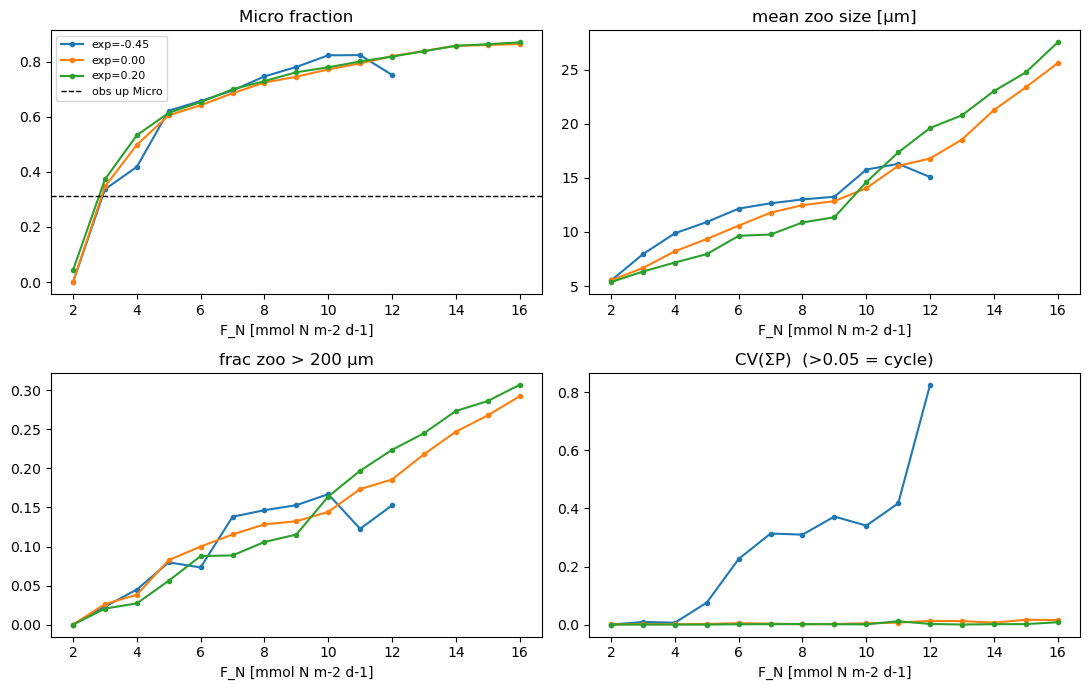

In [5]:
# === diatom_exp x F_N (bloom range) — does Micro / large-Z emerge at high nutrient? ===
EXP_SET  = [-0.45, 0.00, 0.20]                                  # R0, flat, boosted
THR_FIX  = 20.0
FN_VALS  = np.round(np.linspace(2.0, 16.0, 15), 3)
fixed_fn = {k: v for k, v in fixed.items() if k != 'Inflow__FN'}   # keep de + temp; FN is the axis

nX, nF = len(EXP_SET), len(FN_VALS)
Mi=np.full((nX,nF),np.nan); mZ=np.full((nX,nF),np.nan)
fZ2=np.full((nX,nF),np.nan); cvF=np.full((nX,nF),np.nan)
for xi, e in enumerate(EXP_SET):
    res = run_xso_parscan(model_file_name='cariaco_baseline_setups',
                          model_name='model_dist_t3_T_diatom',
                          model_setup_name='model_setup_dist_herb_t3_T_diatom_slim',
                          param_name='Inflow__FN', param_values=FN_VALS, processes=8,
                          fixed_overrides={**fixed_fn, 'Growth__diatom_exp': e,
                                           'Growth__diatom_thresh': THR_FIX})
    for k in range(nF):
        P = res['Phytoplankton__biomass'].isel({'Inflow__FN': k}).values[:, -TAIL:]
        Z = res['Zooplankton__biomass'].isel({'Inflow__FN': k}).values[:, -TAIL:]
        if np.isnan(P).any() or np.isnan(Z).any():
            continue
        Pspec=P.mean(axis=1); b=W@Pspec; f=b/b.sum(); Mi[xi,k]=f[2]
        sP=P.sum(axis=0); cvF[xi,k]=sP.std()/abs(sP.mean())
        Zspec=Z.mean(axis=1); zf=Zspec/Zspec.sum()
        mZ[xi,k]=10.0**(np.log10(zoo_esd)@zf)
        fZ2[xi,k]=Zspec[zoo_esd>200].sum()/Zspec.sum()

fig, ax = plt.subplots(2, 2, figsize=(11, 7))
titles = ['Micro fraction', 'mean zoo size [µm]', 'frac zoo > 200 µm', 'CV(ΣP)  (>0.05 = cycle)']
for a,(Y,t) in zip(ax.ravel(), [(Mi,titles[0]),(mZ,titles[1]),(fZ2,titles[2]),(cvF,titles[3])]):
    for xi,e in enumerate(EXP_SET): a.plot(FN_VALS, Y[xi], marker='o', ms=3, label=f'exp={e:.2f}')
    a.set_title(t); a.set_xlabel('F_N [mmol N m-2 d-1]')
ax[0,0].axhline(obs_frac[2], ls='--', c='k', lw=1, label='obs up Micro')
ax[0,0].legend(fontsize=8); plt.tight_layout(); plt.show()

In [7]:
# === diagnostic print for the diatom_exp x F_N scan (uses arrays already in memory) ===
print(f"{'exp':>6}{'F_N':>7}{'Micro':>7}{'meanZ':>7}{'fZ>200':>8}{'CV':>8}")
for xi, e in enumerate(EXP_SET):
    for k, fn in enumerate(FN_VALS):
        print(f"{e:6.2f}{fn:7.2f}{Mi[xi,k]:7.3f}{mZ[xi,k]:7.1f}{fZ2[xi,k]:8.3f}{cvF[xi,k]:8.4f}")
    print('-' * 43)
print(f"obs upwelling Micro = {obs_frac[2]:.3f}")

   exp    F_N  Micro  meanZ  fZ>200      CV
 -0.45   2.00  0.000    5.5   0.000  0.0006
 -0.45   3.00  0.337    8.0   0.023  0.0094
 -0.45   4.00  0.418    9.9   0.045  0.0069
 -0.45   5.00  0.622   10.9   0.080  0.0762
 -0.45   6.00  0.657   12.2   0.073  0.2263
 -0.45   7.00  0.695   12.7   0.138  0.3137
 -0.45   8.00  0.747   13.0   0.147  0.3099
 -0.45   9.00  0.781   13.3   0.153  0.3722
 -0.45  10.00  0.823   15.8   0.167  0.3409
 -0.45  11.00  0.824   16.3   0.123  0.4173
 -0.45  12.00  0.752   15.1   0.153  0.8256
 -0.45  13.00    nan    nan     nan     nan
 -0.45  14.00    nan    nan     nan     nan
 -0.45  15.00    nan    nan     nan     nan
 -0.45  16.00    nan    nan     nan     nan
-------------------------------------------
  0.00   2.00  0.001    5.5   0.000  0.0007
  0.00   3.00  0.347    6.7   0.026  0.0022
  0.00   4.00  0.498    8.2   0.038  0.0014
  0.00   5.00  0.605    9.4   0.083  0.0024
  0.00   6.00  0.642   10.6   0.100  0.0049
  0.00   7.00  0.685   11.8   0.

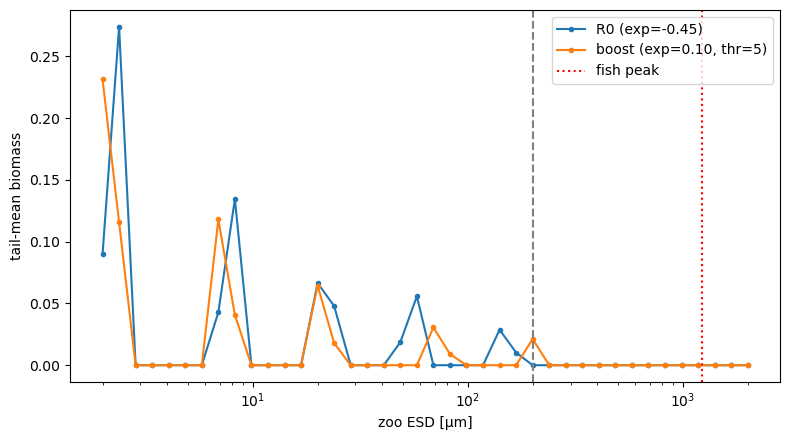

In [6]:
# === verify the >200 µm zoo at thresh=5 is real structure, not a dying tail ===
import matplotlib.pyplot as plt
out_b = pu.run_single_point(cbs.model_dist_t3_T_diatom, cbs.model_setup_dist_herb_t3_T_diatom_slim,
                            scan_params={'Growth__diatom_exp': 0.10, 'Growth__diatom_thresh': 5.0},
                            fixed_overrides=fixed)
out_r = pu.run_single_point(cbs.model_dist_t3_T_diatom, cbs.model_setup_dist_herb_t3_T_diatom_slim,
                            scan_params={'Growth__diatom_exp': -0.45, 'Growth__diatom_thresh': 5.0},
                            fixed_overrides=fixed)
Zb = out_b['Zooplankton__biomass'].values[:, -TAIL:].mean(axis=1)
Zr = out_r['Zooplankton__biomass'].values[:, -TAIL:].mean(axis=1)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(zoo_esd, Zr, marker='o', ms=3, label='R0 (exp=-0.45)')
ax.plot(zoo_esd, Zb, marker='o', ms=3, label='boost (exp=0.10, thr=5)')
ax.axvline(200, ls='--', c='grey'); ax.axvline(1230, ls=':', c='red', label='fish peak')
ax.set_xscale('log')   # log x for the 3-decade size axis (spectrum convention) — say if you'd rather linear/index
ax.set_xlabel('zoo ESD [µm]'); ax.set_ylabel('tail-mean biomass'); ax.legend(); plt.tight_layout(); plt.show()

In [8]:
# === diatom_exp x F_N, augmented: zoo reach toward the fish band ===
EXP_SET  = [-0.45, 0.00, 0.20]; THR_FIX = 20.0
FN_VALS  = np.round(np.linspace(2.0, 16.0, 15), 3)
fixed_fn = {k: v for k, v in fixed.items() if k != 'Inflow__FN'}
nX, nF = len(EXP_SET), len(FN_VALS)
Mi=np.full((nX,nF),np.nan); mZ=np.full((nX,nF),np.nan); z95=np.full((nX,nF),np.nan)
fZ2=np.full((nX,nF),np.nan); fZ8=np.full((nX,nF),np.nan); ZoP=np.full((nX,nF),np.nan); cvF=np.full((nX,nF),np.nan)
for xi, e in enumerate(EXP_SET):
    res = run_xso_parscan(model_file_name='cariaco_baseline_setups',
                          model_name='model_dist_t3_T_diatom',
                          model_setup_name='model_setup_dist_herb_t3_T_diatom_slim',
                          param_name='Inflow__FN', param_values=FN_VALS, processes=8,
                          fixed_overrides={**fixed_fn, 'Growth__diatom_exp': e, 'Growth__diatom_thresh': THR_FIX})
    for k in range(nF):
        P = res['Phytoplankton__biomass'].isel({'Inflow__FN': k}).values[:, -TAIL:]
        Z = res['Zooplankton__biomass'].isel({'Inflow__FN': k}).values[:, -TAIL:]
        if np.isnan(P).any() or np.isnan(Z).any(): continue
        Pspec=P.mean(axis=1); sumP=Pspec.sum(); b=W@Pspec; Mi[xi,k]=(b/b.sum())[2]
        sP=P.sum(axis=0); cvF[xi,k]=sP.std()/abs(sP.mean())
        Zspec=Z.mean(axis=1); sumZ=Zspec.sum(); zf=Zspec/sumZ
        mZ[xi,k]=10.0**(np.log10(zoo_esd)@zf)
        z95[xi,k]=zoo_esd[min(np.searchsorted(np.cumsum(zf),0.95), len(zoo_esd)-1)]
        fZ2[xi,k]=Zspec[zoo_esd>200].sum()/sumZ
        fZ8[xi,k]=Zspec[zoo_esd>825].sum()/sumZ
        ZoP[xi,k]=sumZ/sumP

print(f"{'exp':>6}{'F_N':>6}{'Micro':>7}{'meanZ':>7}{'z95':>7}{'fZ>200':>8}{'fZ>825':>8}{'ZoverP':>8}{'CV':>8}")
for xi, e in enumerate(EXP_SET):
    for k, fn in enumerate(FN_VALS):
        print(f"{e:6.2f}{fn:6.1f}{Mi[xi,k]:7.3f}{mZ[xi,k]:7.1f}{z95[xi,k]:7.0f}"
              f"{fZ2[xi,k]:8.3f}{fZ8[xi,k]:8.3f}{ZoP[xi,k]:8.3f}{cvF[xi,k]:8.4f}")
    print('-'*65)

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T_diatom' and setup 'model_setup_dist_herb_t3_T_diatom_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 15 points using 8 workers...


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=2284 on P[22] = -0.603. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=3939 on P[13] = -0.00101. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=4377 on P[14] = -0.00165. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'i

1D Scan complete. Time taken: 32.60511 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T_diatom' and setup 'model_setup_dist_herb_t3_T_diatom_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 15 points using 8 workers...
1D Scan complete. Time taken: 35.38325 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T_diatom' and setup 'model_setup_dist_herb_t3_T_diatom_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 15 points using 8 workers...
1D Scan complete. Time taken: 37.21215 seconds.
   exp   F_N  Micro  meanZ    z95  fZ>200  fZ>825  ZoverP      CV
 -0.45   2.0  0.000    5.5     69   0.000   0.000   1.719  0.0006
 -0.45   3.0  0.337    8.0    168   0.023   0.000 

In [3]:
# === F_N x fish crosswise on the diatom-boost construct (the core MS3 experiment) ===
RATE_VALS = np.round(np.linspace(0.0, 0.10, 11), 4)   # fish grazing rate; MS3-as-built = 0.005
FN_SET    = [8.0, 10.0, 12.0]                          # stable bloom window (boosted)
EXP_FIX, THR_FIX = 0.20, 20.0
fixed_base = {k: v for k, v in fixed.items() if k != 'Inflow__FN'}   # keep de+temp; FN set per loop

nR = len(RATE_VALS)
Mi=np.full((len(FN_SET),nR),np.nan); mcsP=np.full((len(FN_SET),nR),np.nan)
fZ2=np.full((len(FN_SET),nR),np.nan); sumZ=np.full((len(FN_SET),nR),np.nan); cvF=np.full((len(FN_SET),nR),np.nan)
for fi, fn in enumerate(FN_SET):
    res = run_xso_parscan(model_file_name='cariaco_baseline_setups',
                          model_name='model_dist_t3_T_diatom_fish',
                          model_setup_name='model_setup_dist_herb_t3_T_diatom_fish_slim',
                          param_name='FishGrazing__rate', param_values=RATE_VALS, processes=8,
                          fixed_overrides={**fixed_base, 'Inflow__FN': fn,
                                           'Growth__diatom_exp': EXP_FIX, 'Growth__diatom_thresh': THR_FIX})
    for k in range(nR):
        P = res['Phytoplankton__biomass'].isel({'FishGrazing__rate': k}).values[:, -TAIL:]
        Z = res['Zooplankton__biomass'].isel({'FishGrazing__rate': k}).values[:, -TAIL:]
        if np.isnan(P).any() or np.isnan(Z).any(): continue
        Pspec=P.mean(axis=1); b=W@Pspec; f=b/b.sum()
        Mi[fi,k]=f[2]; mcsP[fi,k]=10.0**(np.log10(geomeans)@f)
        sP=P.sum(axis=0); cvF[fi,k]=sP.std()/abs(sP.mean())
        Zs=Z.mean(axis=1); sumZ[fi,k]=Zs.sum(); fZ2[fi,k]=Zs[zoo_esd>200].sum()/Zs.sum()

print(f"{'F_N':>5}{'rate':>7}{'Micro':>7}{'mcsP':>7}{'fZ>200':>8}{'sumZ':>8}{'CV':>8}")
for fi, fn in enumerate(FN_SET):
    for k, r in enumerate(RATE_VALS):
        print(f"{fn:5.1f}{r:7.3f}{Mi[fi,k]:7.3f}{mcsP[fi,k]:7.2f}{fZ2[fi,k]:8.3f}{sumZ[fi,k]:8.3f}{cvF[fi,k]:8.4f}")
    print('-'*50)

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T_diatom_fish' and setup 'model_setup_dist_herb_t3_T_diatom_fish_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 11 points using 8 workers...
1D Scan complete. Time taken: 38.97924 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T_diatom_fish' and setup 'model_setup_dist_herb_t3_T_diatom_fish_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 11 points using 8 workers...
1D Scan complete. Time taken: 37.7621 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T_diatom_fish' and setup 'model_setup_dist_herb_t3_T_diatom_fish_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceedi

In [4]:
# === herb vs omni across F_N at current params — characterize the omni crash ===
MODELS = [('herb', 'model_setup_dist_herb_t3_T_slim'),
          ('omni', 'model_setup_dist_omni_t3_T_slim')]
FN_VALS  = np.round(np.linspace(2.0, 16.0, 15), 3)
fixed_base = {k: v for k, v in fixed.items() if k != 'Inflow__FN'}   # de+temp+KsZ+ZooLoss

out = {}
for tag, setup in MODELS:
    A = {m: np.full(len(FN_VALS), np.nan) for m in
         ['Micro','mcsP','meanZ','z95','fZ2','ZoP','cv']}
    res = run_xso_parscan(model_file_name='cariaco_baseline_setups',
                          model_name='model_dist_t3_T', model_setup_name=setup,
                          param_name='Inflow__FN', param_values=FN_VALS, processes=8,
                          fixed_overrides=fixed_base)
    for k in range(len(FN_VALS)):
        P = res['Phytoplankton__biomass'].isel({'Inflow__FN': k}).values[:, -TAIL:]
        Z = res['Zooplankton__biomass'].isel({'Inflow__FN': k}).values[:, -TAIL:]
        if np.isnan(P).any() or np.isnan(Z).any(): continue
        Pspec=P.mean(axis=1); sumP=Pspec.sum(); b=W@Pspec; f=b/b.sum()
        A['Micro'][k]=f[2]; A['mcsP'][k]=10.0**(np.log10(geomeans)@f)
        sP=P.sum(axis=0); A['cv'][k]=sP.std()/abs(sP.mean())
        Zs=Z.mean(axis=1); sumZ=Zs.sum(); zf=Zs/sumZ
        A['meanZ'][k]=10.0**(np.log10(zoo_esd)@zf)
        A['z95'][k]=zoo_esd[min(np.searchsorted(np.cumsum(zf),0.95), len(zoo_esd)-1)]
        A['fZ2'][k]=Zs[zoo_esd>200].sum()/sumZ; A['ZoP'][k]=sumZ/sumP
    out[tag]=A

for tag,_ in MODELS:
    A=out[tag]; print(f"\n=== {tag} ===")
    print(f"{'F_N':>5}{'Micro':>7}{'mcsP':>7}{'meanZ':>7}{'z95':>7}{'fZ>200':>8}{'ZoP':>7}{'CV':>8}")
    for k,fn in enumerate(FN_VALS):
        print(f"{fn:5.1f}{A['Micro'][k]:7.3f}{A['mcsP'][k]:7.2f}{A['meanZ'][k]:7.1f}"
              f"{A['z95'][k]:7.0f}{A['fZ2'][k]:8.3f}{A['ZoP'][k]:7.3f}{A['cv'][k]:8.4f}")
        

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T' and setup 'model_setup_dist_herb_t3_T_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 15 points using 8 workers...


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=2943 on P[14] = -0.0011. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=3457 on P[23] = -0.00103. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=3999 on P[22] = -0.00103. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'

1D Scan complete. Time taken: 37.85894 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T' and setup 'model_setup_dist_omni_t3_T_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 15 points using 8 workers...


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=37.68 on N = -2.2. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=42.52 on N = -2.36. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=31.49 on P[0] = -0.00391. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_

1D Scan complete. Time taken: 20.1872 seconds.

=== herb ===
  F_N  Micro   mcsP  meanZ    z95  fZ>200    ZoP      CV
  2.0  0.000   2.71    5.5     69   0.000  1.719  0.0006
  3.0  0.337   7.55    8.0    168   0.023  1.323  0.0094
  4.0  0.418  10.66    9.9    140   0.045  1.053  0.0069
  5.0  0.622  18.50   10.9    200   0.080  0.856  0.0762
  6.0  0.657  20.81   12.2    485   0.073  0.744  0.2262
  7.0  0.696  23.65   12.7    579   0.138  0.659  0.3084
  8.0  0.742  27.41   13.1    579   0.149  0.561  0.2813
  9.0  0.781  30.72   13.3    579   0.153  0.505  0.3723
 10.0    nan    nan    nan    nan     nan    nan     nan
 11.0  0.821  34.91   16.5    579   0.125  0.434  0.4141
 12.0  0.766  31.18   16.4    579   0.188  0.424  0.8353
 13.0    nan    nan    nan    nan     nan    nan     nan
 14.0  0.714  28.68   15.3    579   0.133  0.355  0.8602
 15.0    nan    nan    nan    nan     nan    nan     nan
 16.0    nan    nan    nan    nan     nan    nan     nan

=== omni ===
  F_N  Micro 